# Cache Comparison Test Notebook

This notebook verifies that the bias node caching system works correctly:
1. Values saved to cache are **identical** when loaded back
2. CacheManager correctly populates caches from candle files
3. Both cached and streaming paths produce valid results

**Note:** The cache uses the default project cache directory (`cache/`).

In [1]:
import sys
import os
import tempfile
import shutil
from datetime import datetime
import numpy as np
import pandas as pd

# Add project root to path
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.enums import Ticker, TimeFrame
from utils.models import Candle
from utils.bias_node_cache import BiasNodeCache
from utils.helpers import create_bias_node

# Default cache directory
CACHE_DIR = os.path.join(project_root, 'cache')

print(f"Project root: {project_root}")
print(f"Cache directory: {CACHE_DIR}")

Project root: C:\Users\adabla\Trading-Algo
Cache directory: C:\Users\adabla\Trading-Algo\cache


## Generate Test Data

In [2]:
# Generate synthetic data
np.random.seed(42)
dates = pd.date_range('2020-01-01', '2022-12-31', freq='D')
n = len(dates)

close = 3000 + np.random.randn(n).cumsum() * 10
high = close + np.abs(np.random.randn(n)) * 20
low = close - np.abs(np.random.randn(n)) * 20
open_ = (high + low) / 2 + np.random.randn(n) * 5

candles_df = pd.DataFrame({
    'datetime': dates,
    'open': open_,
    'high': high,
    'low': low,
    'close': close,
    'volume': np.random.randint(1000, 10000, n),
    'ticker': 'ES',
    'timeframe': 'D'
})

# Save to temp directory for CacheManager tests
CANDLE_DIR = tempfile.mkdtemp(prefix='candles_test_')
ticker_dir = os.path.join(CANDLE_DIR, 'ES')
os.makedirs(ticker_dir, exist_ok=True)
candles_df.to_parquet(os.path.join(ticker_dir, 'D.parquet'))

print(f"Generated {len(candles_df)} synthetic candles")
print(f"Temp candle dir: {CANDLE_DIR}")
candles_df.head()

Generated 1096 synthetic candles
Temp candle dir: C:\Users\adabla\AppData\Local\Temp\candles_test_slcb85jw


,datetime,open,high,low,close,volume,ticker,timeframe
0,2020-01-01,2982.371728,3006.539845,2964.480949,3004.967142,4385,ES,D
1,2020-01-02,3008.494571,3043.548512,2976.321018,3003.584499,7636,ES,D
2,2020-01-03,3024.420256,3028.387937,3006.267261,3010.061384,1922,ES,D
3,2020-01-04,3009.697702,3032.221452,3012.052039,3025.291682,9089,ES,D
4,2020-01-05,3035.056205,3042.910351,3014.432405,3022.950149,1564,ES,D


## Part 1: Bias Node Cache Equivalence

Test that values streamed through a bias node, saved to cache, and loaded back are **identical**.

In [3]:
def test_bias_node_cache(module_name, params, ticker, tf, candles_df):
    """
    Test that cached values are identical to streamed values.
    """
    print(f"\n{'='*60}")
    print(f"Testing {module_name.upper()} with params: {params}")
    print(f"{'='*60}")
    
    # Create bias node and stream candles
    bias_node = create_bias_node(module_name, ticker, tf, params)
    datetimes = []
    outputs = []
    
    print(f"Streaming {len(candles_df)} candles...")
    for _, row in candles_df.iterrows():
        candle = Candle.from_row(row)
        result = bias_node.add_candle(candle)
        datetimes.append(candle.datetime)
        outputs.append(result[0] if len(result) > 0 else np.nan)
    
    streaming_values = pd.Series(outputs, index=pd.DatetimeIndex(datetimes))
    print(f"Streamed: {len(streaming_values)} values, {streaming_values.notna().sum()} non-NaN")
    
    # Save to cache
    cache = BiasNodeCache(module_name, params, ticker, tf)
    df_to_save = pd.DataFrame({'value': outputs}, index=pd.DatetimeIndex(datetimes))
    cache.save(df_to_save)
    print(f"Saved to: {cache.cache_path}")
    
    # Load from cache
    cached_values = cache.get_values(datetimes[0], datetimes[-1])
    print(f"Loaded: {len(cached_values)} values")
    
    # Compare
    comparison = pd.DataFrame({'streaming': streaming_values, 'cached': cached_values})
    comparison['diff'] = comparison['streaming'] - comparison['cached']
    
    non_nan = comparison['streaming'].notna() & comparison['cached'].notna()
    max_diff = comparison.loc[non_nan, 'diff'].abs().max() if non_nan.sum() > 0 else 0
    is_identical = np.allclose(
        comparison.loc[non_nan, 'streaming'].values,
        comparison.loc[non_nan, 'cached'].values,
        rtol=1e-10, atol=1e-10
    ) if non_nan.sum() > 0 else True
    
    print(f"\nResults:")
    print(f"  Max difference: {max_diff:.2e}")
    print(f"  Values IDENTICAL: {'YES' if is_identical else 'NO'}")
    
    return {'is_identical': is_identical, 'max_diff': max_diff, 'comparison': comparison}

In [4]:
# Test RSI
rsi_result = test_bias_node_cache('rsi', {'lookback': 14}, Ticker.ES, TimeFrame.D, candles_df)


Testing RSI with params: {'lookback': 14}
Streaming 1096 candles...


Streamed: 1096 values, 1096 non-NaN
Saved to: C:\Users\adabla\Trading-Algo\cache\rsi\ES_D_lookback_14.parquet
Loaded: 1096 values

Results:
  Max difference: 0.00e+00
  Values IDENTICAL: YES


In [5]:
# Test EWMAC
ewmac_result = test_bias_node_cache('ewmac', {'spanFast': 16, 'spanSlow': 64}, Ticker.ES, TimeFrame.D, candles_df)


Testing EWMAC with params: {'spanFast': 16, 'spanSlow': 64}
Streaming 1096 candles...
Streamed: 1096 values, 1096 non-NaN


Saved to: C:\Users\adabla\Trading-Algo\cache\ewmac\ES_D_spanFast_16_spanSlow_64.parquet
Loaded: 1096 values

Results:
  Max difference: 0.00e+00
  Values IDENTICAL: YES


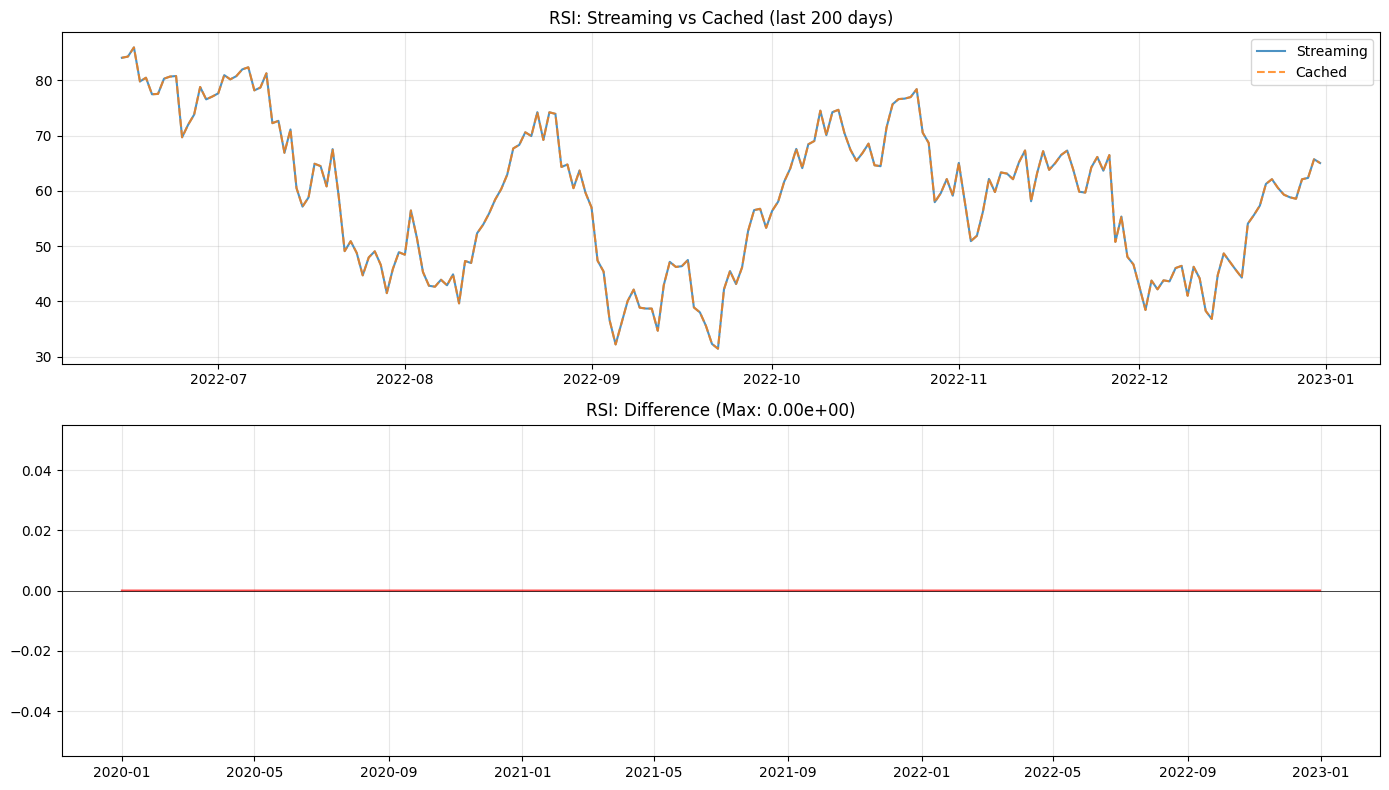

In [6]:
# Visualize RSI comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
comparison = rsi_result['comparison']

ax1 = axes[0]
ax1.plot(comparison.index[-200:], comparison['streaming'][-200:], label='Streaming', alpha=0.8)
ax1.plot(comparison.index[-200:], comparison['cached'][-200:], label='Cached', alpha=0.8, linestyle='--')
ax1.set_title('RSI: Streaming vs Cached (last 200 days)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(comparison.index, comparison['diff'], color='red', alpha=0.7)
ax2.set_title(f'RSI: Difference (Max: {rsi_result["max_diff"]:.2e})')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: CacheManager Test

Test that CacheManager correctly populates caches from candle files.

In [7]:
from utils.cache_manager import CacheManager

# Create CacheManager with temp candle directory
manager = CacheManager(candle_dir=CANDLE_DIR)

# Populate caches for momentum (different params to avoid singleton issues)
specs = [
    {'module_name': 'rsi', 'params': {'lookback': 21}, 'timeframes': [TimeFrame.D]},
    {'module_name': 'momentum', 'params': {'lookback': 20}, 'timeframes': [TimeFrame.D]},
]

print("Populating caches via CacheManager...")
cm_result = manager.populate_cache(
    bias_node_specs=specs,
    tickers=[Ticker.ES],
    start_date=datetime(2020, 1, 1),
    end_date=datetime(2022, 12, 31),
    show_progress=True
)

print(f"\nResult: {cm_result['success']}/{cm_result['total']} successful")

Populating caches via CacheManager...
Populating cache for 2 combinations...
  Bias node specs: 2
  Tickers: 1
  Date range: 2020-01-01 00:00:00 to 2022-12-31 00:00:00
  Max workers: 4


  [1/2] rsi / ES / D
  [2/2] momentum / ES / D

Cache population complete:
  Success: 2/2
  Failed: 0/2
  Skipped: 0/2

Result: 2/2 successful


In [8]:
# Verify caches were created
print("\nVerifying created caches:")
for spec in specs:
    cache = BiasNodeCache(spec['module_name'], spec['params'], Ticker.ES, TimeFrame.D)
    exists = cache.exists()
    if exists:
        vals = cache.get_values(datetime(2020, 1, 1), datetime(2022, 12, 31))
        print(f"  {spec['module_name']}: EXISTS ({len(vals)} values, range [{vals.min():.2f}, {vals.max():.2f}])")
    else:
        print(f"  {spec['module_name']}: MISSING")


Verifying created caches:
  rsi: EXISTS (1096 values, range [25.65, 96.99])
  momentum: EXISTS (1096 values, range [-102.63, 149.72])


In [9]:
# List all caches
print("\nAll caches in directory:")
caches = manager.list_caches()
for c in caches:
    print(f"  - {c['module_name']}/{c['ticker']}_{c['tf']} ({c['file_size_mb']:.3f} MB)")


All caches in directory:
  - ewmac/ES_D (0.020 MB)
  - momentum/ES_D (0.021 MB)
  - rsi/ES_D (0.021 MB)
  - rsi/ES_D (0.021 MB)


## Part 3: BaseModel Test

Test BaseModel with streaming path (use_cache=False) to verify it works correctly.

In [10]:
from feature_selection.base_models.feature_base_model import BaseModel
import time

# Generate target data
target_df = candles_df.copy()
target_df['target'] = target_df['close'].pct_change().shift(-1)
target_data = target_df[['datetime', 'target']].dropna()

print(f"Candles: {len(candles_df)} rows")
print(f"Target data: {len(target_data)} rows")

Candles: 1096 rows
Target data: 1095 rows


In [11]:
# Test streaming path with unique params
print("\n=== Testing BaseModel (Streaming Path) ===")

stream_config = {
    'bias_node_spec': {
        'module_name': 'rsi',
        'params': {'lookback': 7},  # Unique params
        'timeframes': [TimeFrame.D]
    }
}

model_stream = BaseModel(
    feature_config=stream_config,
    tickers=[Ticker.ES],
    use_cache=False
)

print("Fitting...")
t0 = time.time()
model_stream.stream_fit(candles_df, target_data)
fit_time = time.time() - t0
print(f"  Fit time: {fit_time:.2f}s")
print(f"  Model fitted: {model_stream.binning_model.is_fitted_}")

print("\nPredicting...")
t0 = time.time()
pred = model_stream.stream_predict(candles_df, strategy='long')
pred_time = time.time() - t0
print(f"  Predict time: {pred_time:.2f}s")
# Check if pred is valid (not None and not empty)
pred_valid = pred is not None and (len(pred) > 0 if hasattr(pred, '__len__') else True)
print(f"  Predictions: {'OK (' + str(len(pred)) + ' values)' if pred_valid else 'None'}")

stream_pass = model_stream.binning_model.is_fitted_ and pred_valid


=== Testing BaseModel (Streaming Path) ===
Fitting...
  Fit time: 0.08s
  Model fitted: True

Predicting...
  Predict time: 0.11s
  Predictions: OK (1096 values)


## Summary Report

In [12]:
print("="*60)
print("CACHE COMPARISON TEST SUMMARY")
print("="*60)

print(f"\n1. RSI Bias Node Cache:")
print(f"   - Streaming vs Cached IDENTICAL: {'PASS' if rsi_result['is_identical'] else 'FAIL'}")
print(f"   - Max difference: {rsi_result['max_diff']:.2e}")

print(f"\n2. EWMAC Bias Node Cache:")
print(f"   - Streaming vs Cached IDENTICAL: {'PASS' if ewmac_result['is_identical'] else 'FAIL'}")
print(f"   - Max difference: {ewmac_result['max_diff']:.2e}")

cm_pass = cm_result['success'] == cm_result['total']
print(f"\n3. CacheManager:")
print(f"   - All caches created: {'PASS' if cm_pass else 'FAIL'} ({cm_result['success']}/{cm_result['total']})")

print(f"\n4. BaseModel (Streaming):")
print(f"   - Fit and predict work: {'PASS' if stream_pass else 'FAIL'}")

all_pass = rsi_result['is_identical'] and ewmac_result['is_identical'] and cm_pass and stream_pass
print(f"\n" + "="*60)
print(f"OVERALL RESULT: {'ALL TESTS PASSED' if all_pass else 'SOME TESTS FAILED'}")
print("="*60)

CACHE COMPARISON TEST SUMMARY

1. RSI Bias Node Cache:
   - Streaming vs Cached IDENTICAL: PASS
   - Max difference: 0.00e+00

2. EWMAC Bias Node Cache:
   - Streaming vs Cached IDENTICAL: PASS
   - Max difference: 0.00e+00

3. CacheManager:
   - All caches created: PASS (2/2)

4. BaseModel (Streaming):
   - Fit and predict work: PASS

OVERALL RESULT: ALL TESTS PASSED


In [13]:
# Cleanup temp candle directory
print("\nCleaning up...")
if os.path.exists(CANDLE_DIR):
    shutil.rmtree(CANDLE_DIR)
    print(f"  Removed temp candle dir: {CANDLE_DIR}")
print("Done!")


Cleaning up...
  Removed temp candle dir: C:\Users\adabla\AppData\Local\Temp\candles_test_slcb85jw
Done!
